Machine Learning guide

step 1 Import all libraries

step 2 import dataset using pandas(pd.read_csv,pd.raed_xlsv)

step 3 eda or preprocessing our dataset

step 4 Target variables select(x,y(x is input data,y is output data))

step 5 data divide into two parts training,testing(x,y both) train_test_split()

step 6 import model(lr=linearregression)

step 7 training data will be fit on model(lr.fit(x_train,y_train))

step 8 make predictions(lr.predict(x_test))

step 9 check model evaluation matrices (r2score,mse,mae,f1score,precision,recall,accuracy score)

step 10 conevrt model into pkl file and then we will make gui and make prediction using frontend


Linear Regression

In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle




In [23]:

df = pd.read_csv("Salary_Data.csv")

In [24]:
df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [25]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [26]:
df.dropna(inplace=True) #Exact match ke liye inplace use kiya

In [27]:
df.shape

(30, 2)

In [28]:
x=df[['YearsExperience']] #double esiliye use kiya taki dataframe le
y=df['Salary'] #single use kiya taki as series le

In [40]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr=LinearRegression()

In [32]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [33]:
y_pred=lr.predict(X_test)


In [34]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [35]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [43]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test ,y_pred)

In [44]:
r2

0.9024461774180497

In [39]:
m = lr.coef_
m

array([9423.81532303])

In [45]:
c = lr.intercept_
c

np.float64(25321.583011776813)

In [48]:
m *4.0  + c

array([63016.8443039])

In [58]:
#m=model.pickle("Linear_Regression_Batch_1")
import pickle

pickle.dump(lr, open("Salary_Prediction_Model.pkl", "wb"))

In [59]:
import pickle

model = pickle.load(open("Salary_Prediction_Model.pkl", "rb"))

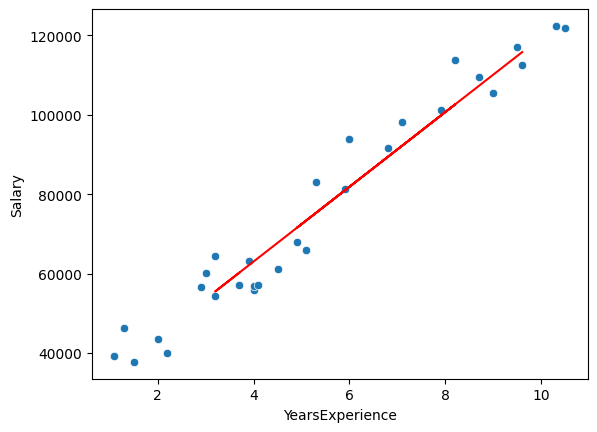

In [60]:
#sns.scatterplot(x = 'Years of Experience', 'age' , y = 'Salary' , data = df)
#plt.plot(X_test , lr.predict(X_test) , color = 'red')

sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.plot(X_test['YearsExperience'], lr.predict(X_test), color='red')
plt.show()